# PlantVillage Dataset — Inspection, EDA, Quality Audit & Cleaning

This notebook merges the four earlier notebooks (dataset inspection, image quality audit, exploratory data analysis, and data cleaning) into a single workflow. Repeated steps (imports, inventory, class counts, dimension checks, random samples, hashing) now run once and feed every later section.

## Contents

1. Setup and configuration
2. Dataset inventory
3. Class distribution and imbalance
4. Image integrity and dimensions
5. Pixel-level measurements (quality and color)
6. Color characteristics
7. Visual exploration
8. Image quality audit
9. Duplicate and near-duplicate detection
10. Data cleaning decisions
11. Export and final summary

> **Important:** Source images are never deleted, moved, or modified. Every cleaning decision is recorded in a table and exported as CSV. The expected image count for this project is 54,305; the notebook reports what it actually finds and does not force that number.

In [1]:
from pathlib import Path
import hashlib
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import imagehash
from IPython.display import display
from PIL import Image, ImageOps
from tqdm.auto import tqdm

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

# ---- Configuration ----
DATA_DIR = Path(
    r"C:\Users\omarw\Downloads\PlantVillage_Project\data\raw\PlantVillage-Dataset\raw\color"
)
OUTPUT_DIR = Path("reports")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}
EXPECTED_IMAGE_COUNT = 54305

print("Dataset directory:", DATA_DIR)
print("Directory exists:", DATA_DIR.exists())
print("Output directory:", OUTPUT_DIR.resolve())

Dataset directory: C:\Users\omarw\Downloads\PlantVillage_Project\data\raw\PlantVillage-Dataset\raw\color
Directory exists: True
Output directory: C:\Users\omarw\Downloads\PlantVillage_Project\notebooks\reports


c:\Users\omarw\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Dataset Inventory

### Objective
Build one canonical inventory of the images that every later section uses.

### Dataset scope
All analyses use the class directories located directly under `DATA_DIR`. Separate folders outside those class directories (including the SVM data-distribution folder) are not part of this inventory. The class of an image is the first folder under `DATA_DIR`.

In [2]:
if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Dataset directory not found: {DATA_DIR}\n"
        "Update DATA_DIR to the folder containing the PlantVillage class directories."
    )

class_folders = sorted(folder for folder in DATA_DIR.iterdir() if folder.is_dir())

image_paths = sorted(
    path
    for folder in class_folders
    for path in folder.rglob("*")
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
)


def get_class_name(image_path):
    # Top-level class folder under DATA_DIR
    return Path(image_path).relative_to(DATA_DIR).parts[0]


inventory_df = pd.DataFrame({
    "path": [str(p) for p in image_paths],
    "relative_path": [str(p.relative_to(DATA_DIR)) for p in image_paths],
    "filename": [p.name for p in image_paths],
    "class": [get_class_name(p) for p in image_paths],
    "extension": [p.suffix.lower() for p in image_paths],
    "file_size_bytes": [p.stat().st_size for p in image_paths],
})

if inventory_df.empty:
    raise ValueError("No supported images were found. Check DATA_DIR.")

print("DATASET INVENTORY")
print("=" * 45)
print("Class folders:", len(class_folders))
print("Images found:", f"{len(inventory_df):,}")
print("Expected reference count:", f"{EXPECTED_IMAGE_COUNT:,}")
print("Count matches expected:", len(inventory_df) == EXPECTED_IMAGE_COUNT)

display(inventory_df.head())

DATASET INVENTORY
Class folders: 38
Images found: 54,305
Expected reference count: 54,305
Count matches expected: True


,path,relative_path,filename,class,extension,file_size_bytes
0,C:\Users\omarw\Downloads\PlantVillage_Project\...,Apple___Apple_scab\00075aa8-d81a-4184-8541-b69...,00075aa8-d81a-4184-8541-b692b78d398a___FREC_Sc...,Apple___Apple_scab,.jpg,9616
1,C:\Users\omarw\Downloads\PlantVillage_Project\...,Apple___Apple_scab\01a66316-0e98-4d3b-a56f-d78...,01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Sc...,Apple___Apple_scab,.jpg,10108
2,C:\Users\omarw\Downloads\PlantVillage_Project\...,Apple___Apple_scab\01f3deaa-6143-4b6c-9c22-620...,01f3deaa-6143-4b6c-9c22-620a46d8be04___FREC_Sc...,Apple___Apple_scab,.jpg,12005
3,C:\Users\omarw\Downloads\PlantVillage_Project\...,Apple___Apple_scab\0208f4eb-45a4-4399-904e-989...,0208f4eb-45a4-4399-904e-989ac2c6257c___FREC_Sc...,Apple___Apple_scab,.jpg,19474
4,C:\Users\omarw\Downloads\PlantVillage_Project\...,Apple___Apple_scab\023123cb-7b69-4c9f-a521-766...,023123cb-7b69-4c9f-a521-766d7c8543bb___FREC_Sc...,Apple___Apple_scab,.jpg,8897


## 3. Class Distribution and Imbalance

### Objective
Count the images in each class, show how they are distributed, and measure how imbalanced the dataset is.

In [3]:
class_distribution_df = (
    inventory_df["class"]
    .value_counts()
    .rename_axis("class")
    .reset_index(name="image_count")
)
class_distribution_df["percentage"] = (
    class_distribution_df["image_count"] / len(inventory_df) * 100
)

print("Total classes:", len(class_distribution_df))
print("Total images:", int(class_distribution_df["image_count"].sum()))
display(class_distribution_df.round({"percentage": 3}))

Total classes: 38
Total images: 54305


,class,image_count,percentage
0,Orange___Haunglongbing_(Citrus_greening),5507,10.141
1,Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357,9.865
2,Soybean___healthy,5090,9.373
3,Peach___Bacterial_spot,2297,4.230
4,Tomato___Bacterial_spot,2127,3.917
5,Tomato___Late_blight,1909,3.515
6,Squash___Powdery_mildew,1835,3.379
7,Tomato___Septoria_leaf_spot,1771,3.261
8,Tomato___Spider_mites Two-spotted_spider_mite,1676,3.086
9,Apple___healthy,1645,3.029


### 3.1 Class Distribution Chart

A horizontal bar chart keeps long class names readable and shows which classes are under- or over-represented.

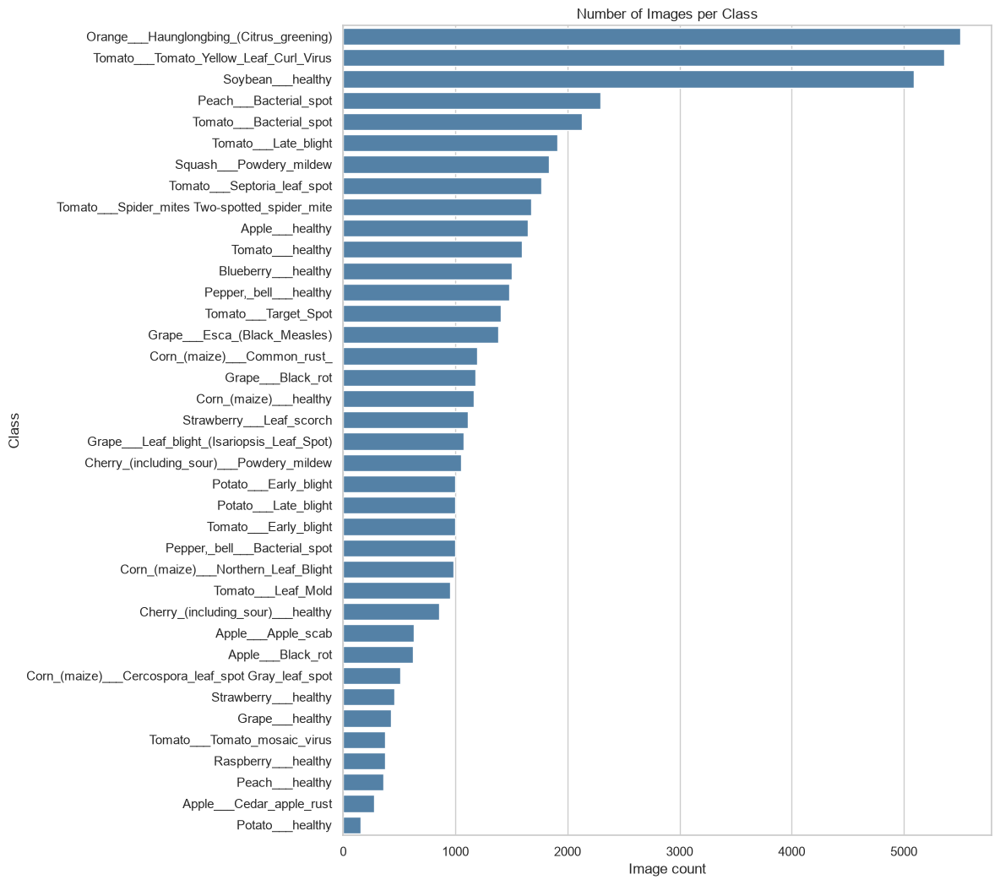

In [4]:
plt.figure(figsize=(12, max(6, len(class_distribution_df) * 0.28)))
sns.barplot(
    data=class_distribution_df,
    y="class",
    x="image_count",
    color="steelblue"
)
plt.title("Number of Images per Class")
plt.xlabel("Image count")
plt.ylabel("Class")
plt.tight_layout()
plt.show()

### 3.2 Class Imbalance Summary

The imbalance ratio is the size of the largest class divided by the size of the smallest class. A ratio near 1 means a balanced dataset; a higher ratio means stronger imbalance.

In [5]:
largest_class = class_distribution_df.iloc[0]
smallest_class = class_distribution_df.iloc[-1]
imbalance_ratio = largest_class["image_count"] / smallest_class["image_count"]

print("CLASS IMBALANCE SUMMARY")
print("=" * 45)
print(f"Largest class:  {largest_class['class']} ({int(largest_class['image_count'])} images)")
print(f"Smallest class: {smallest_class['class']} ({int(smallest_class['image_count'])} images)")
print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

CLASS IMBALANCE SUMMARY
Largest class:  Orange___Haunglongbing_(Citrus_greening) (5507 images)
Smallest class: Potato___healthy (152 images)
Imbalance ratio: 36.23:1


## 4. Image Integrity and Dimensions

### Objective
Check every file once: confirm it opens and fully decodes, then record its format, color mode, and size. The results feed the dimension analysis here and the cleaning decisions in Section 10.

### 4.1 Validate Every Image

`verify()` checks file structure but does not decode pixels, so each file is reopened and fully loaded. Zero-byte and unreadable files are marked `invalid`; nothing is removed from disk.

In [6]:
image_info = []

for path_string in tqdm(inventory_df["path"], desc="Validating images"):
    info = {
        "image_format": None,
        "mode": None,
        "width": np.nan,
        "height": np.nan,
        "status": "valid",
        "error": None,
    }
    try:
        if Path(path_string).stat().st_size == 0:
            raise ValueError("Zero-byte file")

        with Image.open(path_string) as img:
            img.verify()

        # Reopen and force pixel decoding after verify()
        with Image.open(path_string) as img:
            img.load()
            info["image_format"] = img.format
            info["mode"] = img.mode
            info["width"], info["height"] = ImageOps.exif_transpose(img).size

    except Exception as exc:
        info["status"] = "invalid"
        info["error"] = f"{type(exc).__name__}: {exc}"

    image_info.append(info)

validation_df = pd.concat([inventory_df, pd.DataFrame(image_info)], axis=1)

valid_df = validation_df[validation_df["status"] == "valid"].copy()
invalid_df = validation_df[validation_df["status"] == "invalid"].copy()

print("Images scanned:", len(validation_df))
print("Readable images:", len(valid_df))
print("Unreadable images:", len(invalid_df))

print("\nImage modes:")
display(validation_df["mode"].value_counts(dropna=False))

print("\nImage extensions:")
display(validation_df["extension"].value_counts())

print("\nInvalid images (first 20):")
display(invalid_df[["relative_path", "file_size_bytes", "error"]].head(20))

Validating images: 100%|██████████| 54305/54305 [01:07<00:00, 810.41it/s]

Images scanned: 54305
Readable images: 54305
Unreadable images: 0

Image modes:


mode
RGB     54304
RGBA        1
Name: count, dtype: int64


Image extensions:


extension
.jpg     54303
.png         1
.jpeg        1
Name: count, dtype: int64


Invalid images (first 20):


,relative_path,file_size_bytes,error


### 4.2 Dimension and Aspect-Ratio Statistics

Only readable images are included. Unusual resolutions are flagged with the IQR rule on total pixel count; they are candidates for review, not defects.

In [7]:
valid_df["aspect_ratio"] = valid_df["width"] / valid_df["height"]
valid_df["total_pixels"] = valid_df["width"] * valid_df["height"]
valid_df["megapixels"] = valid_df["total_pixels"] / 1_000_000

print("IMAGE DIMENSIONS SUMMARY")
print("=" * 50)
display(
    valid_df[["width", "height", "aspect_ratio", "total_pixels", "megapixels"]]
    .describe().round(3)
)

# Most common image sizes
size_distribution_df = (
    valid_df
    .groupby(["width", "height"])
    .size()
    .reset_index(name="image_count")
    .sort_values("image_count", ascending=False)
)

print("\nMost common image dimensions:")
display(size_distribution_df.head(15))
print("Number of unique dimensions:", len(size_distribution_df))

# Aspect-ratio distribution
print("\nASPECT RATIO DISTRIBUTION")
print("=" * 50)
display(
    valid_df["aspect_ratio"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .to_frame()
)

# Resolution outliers (IQR rule)
Q1 = valid_df["total_pixels"].quantile(0.25)
Q3 = valid_df["total_pixels"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = max(0, Q1 - 1.5 * IQR)
upper_bound = Q3 + 1.5 * IQR

valid_df["resolution_outlier"] = (
    (valid_df["total_pixels"] < lower_bound)
    | (valid_df["total_pixels"] > upper_bound)
)

print("\nRESOLUTION OUTLIER ANALYSIS")
print("=" * 50)
print("Lower bound:", round(lower_bound))
print("Upper bound:", round(upper_bound))
print("Potential resolution outliers:", int(valid_df["resolution_outlier"].sum()))

# Class-level resolution statistics
class_resolution_stats = (
    valid_df
    .groupby("class")
    .agg(
        image_count=("filename", "count"),
        mean_width=("width", "mean"),
        mean_height=("height", "mean"),
        mean_megapixels=("megapixels", "mean"),
        min_megapixels=("megapixels", "min"),
        max_megapixels=("megapixels", "max"),
        unique_dimensions=("total_pixels", "nunique"),
    )
    .sort_values("mean_megapixels", ascending=False)
)

print("\nCLASS-LEVEL RESOLUTION STATISTICS")
display(class_resolution_stats.round(3))

IMAGE DIMENSIONS SUMMARY


,width,height,aspect_ratio,total_pixels,megapixels
count,54305.0,54305.0,54305.0,54305.0,54305.000
mean,256.0,256.0,1.0,65536.0,0.066
std,0.0,0.0,0.0,0.0,0.000
min,256.0,256.0,1.0,65536.0,0.066
25%,256.0,256.0,1.0,65536.0,0.066
50%,256.0,256.0,1.0,65536.0,0.066
75%,256.0,256.0,1.0,65536.0,0.066
max,256.0,256.0,1.0,65536.0,0.066



Most common image dimensions:


,width,height,image_count
0,256,256,54305


Number of unique dimensions: 1

ASPECT RATIO DISTRIBUTION


,aspect_ratio
count,54305.0
mean,1.0
std,0.0
min,1.0
1%,1.0
5%,1.0
25%,1.0
50%,1.0
75%,1.0
95%,1.0



RESOLUTION OUTLIER ANALYSIS
Lower bound: 65536
Upper bound: 65536
Potential resolution outliers: 0

CLASS-LEVEL RESOLUTION STATISTICS


,image_count,mean_width,mean_height,mean_megapixels,min_megapixels,max_megapixels,unique_dimensions
class,,,,,,,
Apple___Apple_scab,630,256.0,256.0,0.066,0.066,0.066,1
Apple___Black_rot,621,256.0,256.0,0.066,0.066,0.066,1
Apple___Cedar_apple_rust,275,256.0,256.0,0.066,0.066,0.066,1
Apple___healthy,1645,256.0,256.0,0.066,0.066,0.066,1
Blueberry___healthy,1502,256.0,256.0,0.066,0.066,0.066,1
Cherry_(including_sour)___Powdery_mildew,1052,256.0,256.0,0.066,0.066,0.066,1
Cherry_(including_sour)___healthy,854,256.0,256.0,0.066,0.066,0.066,1
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,513,256.0,256.0,0.066,0.066,0.066,1
Corn_(maize)___Common_rust_,1192,256.0,256.0,0.066,0.066,0.066,1


### 4.3 Dimension Distributions

Plot width, height, and aspect ratio to see the common image sizes and any variation in shape.

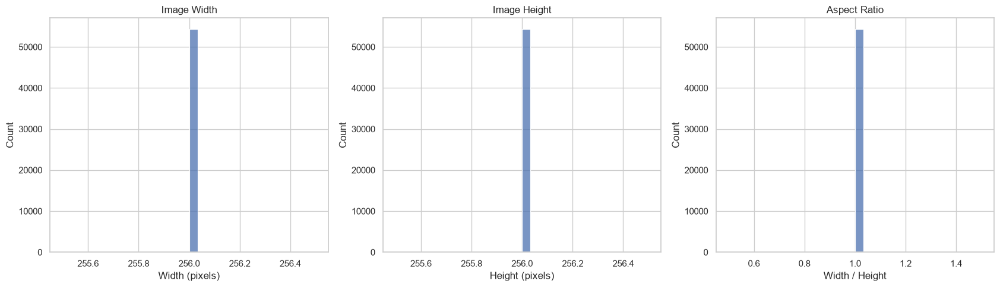

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.histplot(valid_df["width"], bins=30, ax=axes[0])
axes[0].set_title("Image Width")
axes[0].set_xlabel("Width (pixels)")

sns.histplot(valid_df["height"], bins=30, ax=axes[1])
axes[1].set_title("Image Height")
axes[1].set_xlabel("Height (pixels)")

sns.histplot(valid_df["aspect_ratio"], bins=30, ax=axes[2])
axes[2].set_title("Aspect Ratio")
axes[2].set_xlabel("Width / Height")

plt.tight_layout()
plt.show()

## 5. Pixel-Level Measurements (Quality and Color)

### Objective
Read each readable image once and record every pixel-based measurement needed for the color analysis (Section 6) and the quality audit (Section 8).

### Metrics

- **Brightness:** mean grayscale pixel intensity (0–255).
- **Contrast:** standard deviation of grayscale intensity.
- **Dark-pixel percentage:** percentage of grayscale pixels at or below 10.
- **Bright-pixel percentage:** percentage of grayscale pixels at or above 245.
- **Saturation:** mean HSV saturation (0–255).
- **Sharpness proxy:** variance of a 4-neighbor Laplacian response. Low values may indicate blur, but image content and texture also affect this metric.
- **Mean RGB:** mean red, green, and blue channel values. These are descriptive summaries and not disease indicators on their own.

In [9]:
quality_records = []

for path_string, class_name, filename in tqdm(
    zip(valid_df["path"], valid_df["class"], valid_df["filename"]),
    total=len(valid_df),
    desc="Measuring images"
):
    record = {
        "class": class_name,
        "filename": filename,
        "path": path_string,
        "brightness": np.nan,
        "contrast": np.nan,
        "dark_pixel_pct": np.nan,
        "bright_pixel_pct": np.nan,
        "mean_saturation": np.nan,
        "sharpness_laplacian_var": np.nan,
        "mean_red": np.nan,
        "mean_green": np.nan,
        "mean_blue": np.nan,
        "status": "valid",
        "error": None,
    }

    try:
        with Image.open(path_string) as source:
            image = ImageOps.exif_transpose(source).convert("RGB")
            rgb = np.asarray(image, dtype=np.float32)
            gray = np.asarray(image.convert("L"), dtype=np.float32)
            hsv = np.asarray(image.convert("HSV"), dtype=np.uint8)

        record["brightness"] = float(gray.mean())
        record["contrast"] = float(gray.std())
        record["dark_pixel_pct"] = float(np.mean(gray <= 10) * 100)
        record["bright_pixel_pct"] = float(np.mean(gray >= 245) * 100)
        record["mean_saturation"] = float(hsv[:, :, 1].mean())
        record["mean_red"] = float(rgb[:, :, 0].mean())
        record["mean_green"] = float(rgb[:, :, 1].mean())
        record["mean_blue"] = float(rgb[:, :, 2].mean())

        # 4-neighbor discrete Laplacian; its variance is a sharpness proxy
        if gray.shape[0] >= 3 and gray.shape[1] >= 3:
            center = gray[1:-1, 1:-1]
            laplacian = (
                4 * center
                - gray[:-2, 1:-1]
                - gray[2:, 1:-1]
                - gray[1:-1, :-2]
                - gray[1:-1, 2:]
            )
            record["sharpness_laplacian_var"] = float(laplacian.var())

    except Exception as exc:
        record["status"] = "invalid"
        record["error"] = str(exc)

    quality_records.append(record)

quality_df = pd.DataFrame(quality_records)
valid_quality_df = quality_df[quality_df["status"] == "valid"].copy()

print("Images measured:", len(quality_df))
print("Measured successfully:", len(valid_quality_df))
print("Failed during measurement:", len(quality_df) - len(valid_quality_df))
display(quality_df.head())

Measuring images: 100%|██████████| 54305/54305 [04:13<00:00, 214.07it/s]


Images measured: 54305
Measured successfully: 54305
Failed during measurement: 0


,class,filename,path,brightness,contrast,dark_pixel_pct,bright_pixel_pct,mean_saturation,sharpness_laplacian_var,mean_red,mean_green,mean_blue,status,error
0,Apple___Apple_scab,00075aa8-d81a-4184-8541-b692b78d398a___FREC_Sc...,C:\Users\omarw\Downloads\PlantVillage_Project\...,123.143341,39.137341,0.000000,0.000000,74.568985,140.774780,110.662399,130.183029,119.862732,valid,None
1,Apple___Apple_scab,01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Sc...,C:\Users\omarw\Downloads\PlantVillage_Project\...,94.179001,26.618652,0.000000,0.000000,78.301788,324.741760,84.160263,97.555771,103.142639,valid,None
2,Apple___Apple_scab,01f3deaa-6143-4b6c-9c22-620a46d8be04___FREC_Sc...,C:\Users\omarw\Downloads\PlantVillage_Project\...,114.686539,30.973890,0.000000,0.915527,83.356201,773.544006,92.535965,125.726334,116.025253,valid,None
3,Apple___Apple_scab,0208f4eb-45a4-4399-904e-989ac2c6257c___FREC_Sc...,C:\Users\omarw\Downloads\PlantVillage_Project\...,125.654114,58.039425,0.064087,0.680542,62.041458,6129.914062,129.896759,125.648727,114.409760,valid,None
4,Apple___Apple_scab,023123cb-7b69-4c9f-a521-766d7c8543bb___FREC_Sc...,C:\Users\omarw\Downloads\PlantVillage_Project\...,97.199753,31.854883,0.013733,0.000000,66.591934,221.333725,86.708450,101.711456,101.433350,valid,None


## 6. Color Characteristics

Mean RGB values describe broad color variation. Differences between classes may reflect plant appearance, background, or capture conditions; they are not proof of a class-specific visual feature.

### 6.1 Overall RGB Distributions

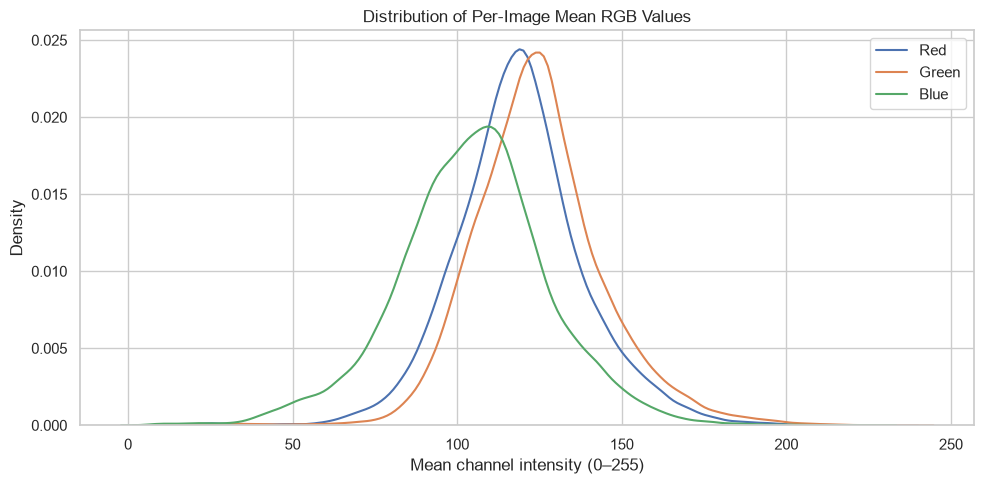

In [10]:
rgb_columns = ["mean_red", "mean_green", "mean_blue"]

plt.figure(figsize=(10, 5))
for column in rgb_columns:
    sns.kdeplot(
        data=valid_quality_df,
        x=column,
        label=column.replace("mean_", "").title()
    )
plt.title("Distribution of Per-Image Mean RGB Values")
plt.xlabel("Mean channel intensity (0–255)")
plt.legend()
plt.tight_layout()
plt.show()

### 6.2 Mean RGB Values by Class

,mean_red,mean_green,mean_blue
class,,,
Apple___Apple_scab,103.54,114.37,106.17
Apple___Black_rot,118.78,125.72,113.70
Apple___Cedar_apple_rust,118.34,124.82,101.15
Apple___healthy,109.55,116.64,116.35
Blueberry___healthy,140.55,145.39,136.08
Cherry_(including_sour)___Powdery_mildew,116.12,123.18,103.71
Cherry_(including_sour)___healthy,138.31,144.49,121.17
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,117.38,123.28,97.79
Corn_(maize)___Common_rust_,89.14,97.03,69.35


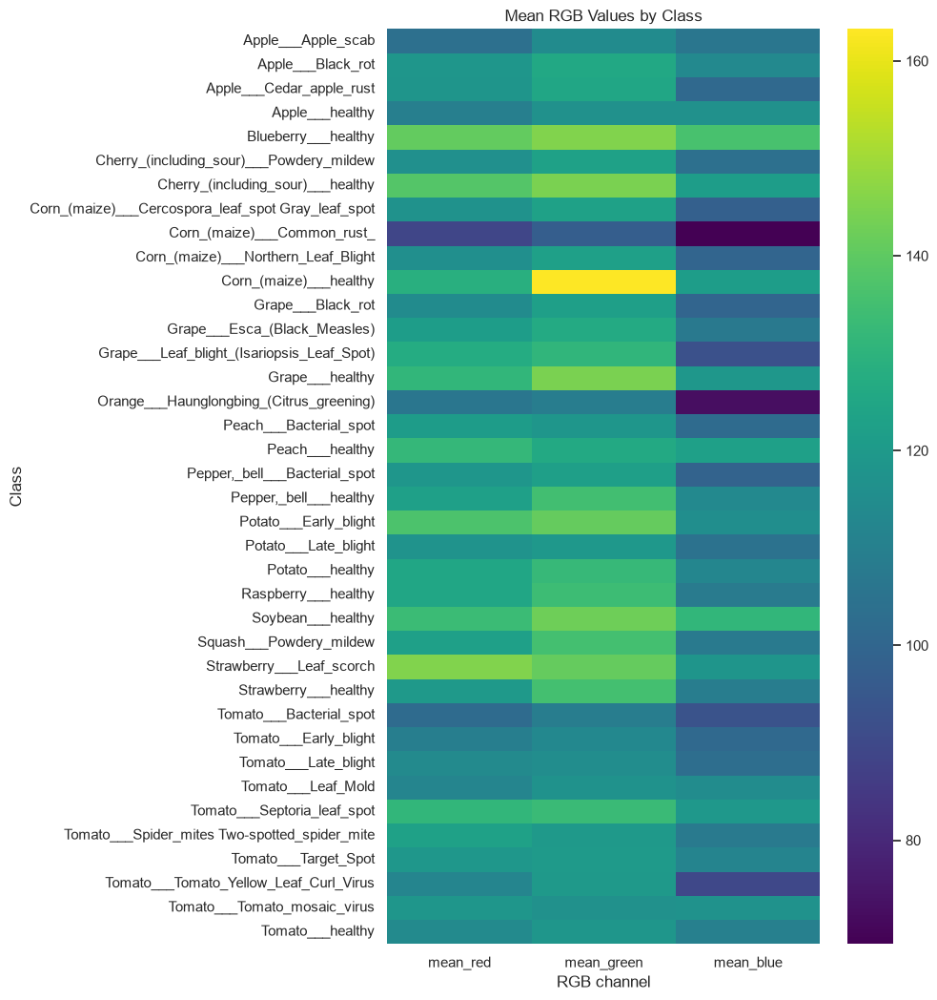

In [11]:
class_color_summary = (
    valid_quality_df.groupby("class")[rgb_columns]
    .mean()
    .sort_index()
)

display(class_color_summary.round(2))

plt.figure(figsize=(10, max(6, len(class_color_summary) * 0.28)))
sns.heatmap(class_color_summary, cmap="viridis", annot=False)
plt.title("Mean RGB Values by Class")
plt.xlabel("RGB channel")
plt.ylabel("Class")
plt.tight_layout()
plt.show()

## 7. Visual Exploration

### Objective
Inspect examples from the dataset to understand variation in plant species, disease symptoms, backgrounds, lighting, and framing.

### 7.1 Random Samples

A reproducible random sample of readable images, with the class label above each image.

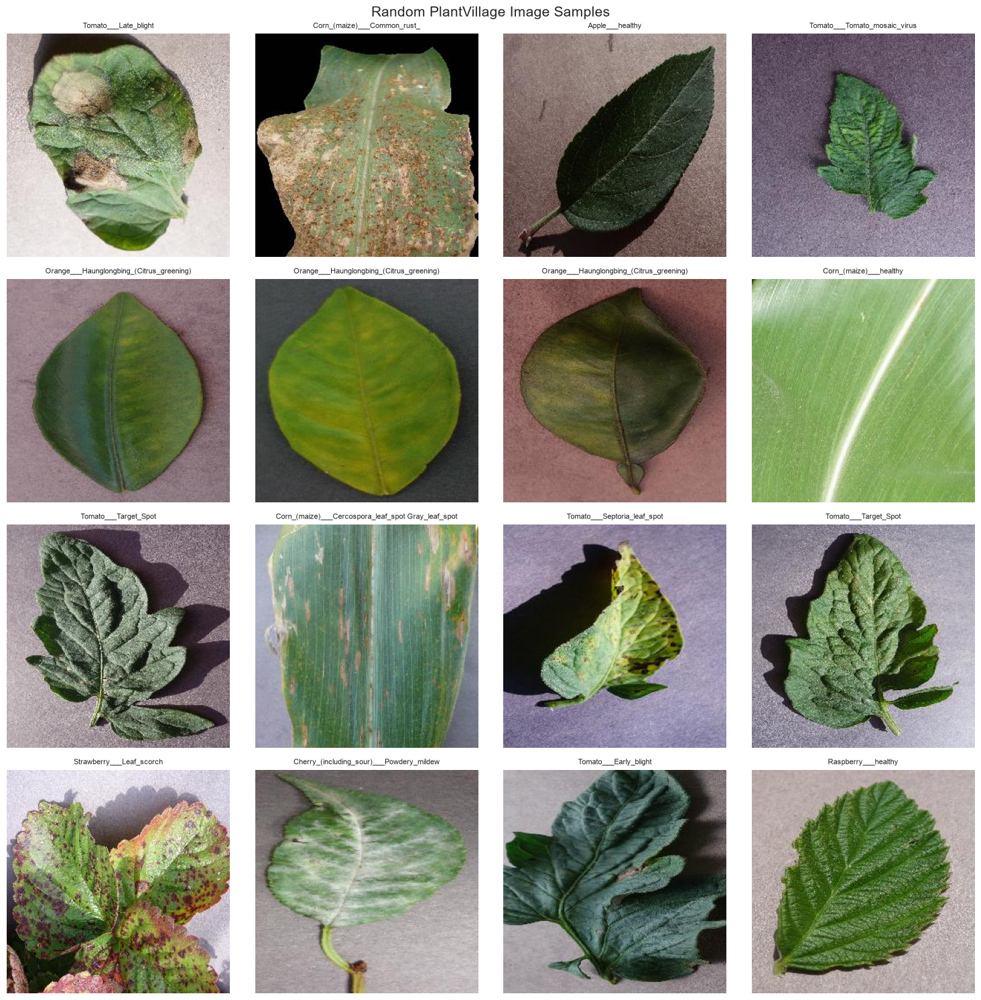

In [12]:
rng = random.Random(RANDOM_STATE)

sample_size = min(16, len(valid_df))
sample_paths = rng.sample(valid_df["path"].tolist(), sample_size)

ncols = 4
nrows = int(np.ceil(sample_size / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.8 * nrows))
axes = np.array(axes).reshape(-1)

for ax, path_string in zip(axes, sample_paths):
    with Image.open(path_string) as source:
        ax.imshow(ImageOps.exif_transpose(source).convert("RGB"))
    ax.set_title(get_class_name(path_string), fontsize=8)
    ax.axis("off")

for ax in axes[sample_size:]:
    ax.axis("off")

plt.suptitle("Random PlantVillage Image Samples", fontsize=15)
plt.tight_layout()
plt.show()

### 7.2 Samples Within Selected Classes

Four examples from each of the four largest classes make it easier to compare variation within and between classes.

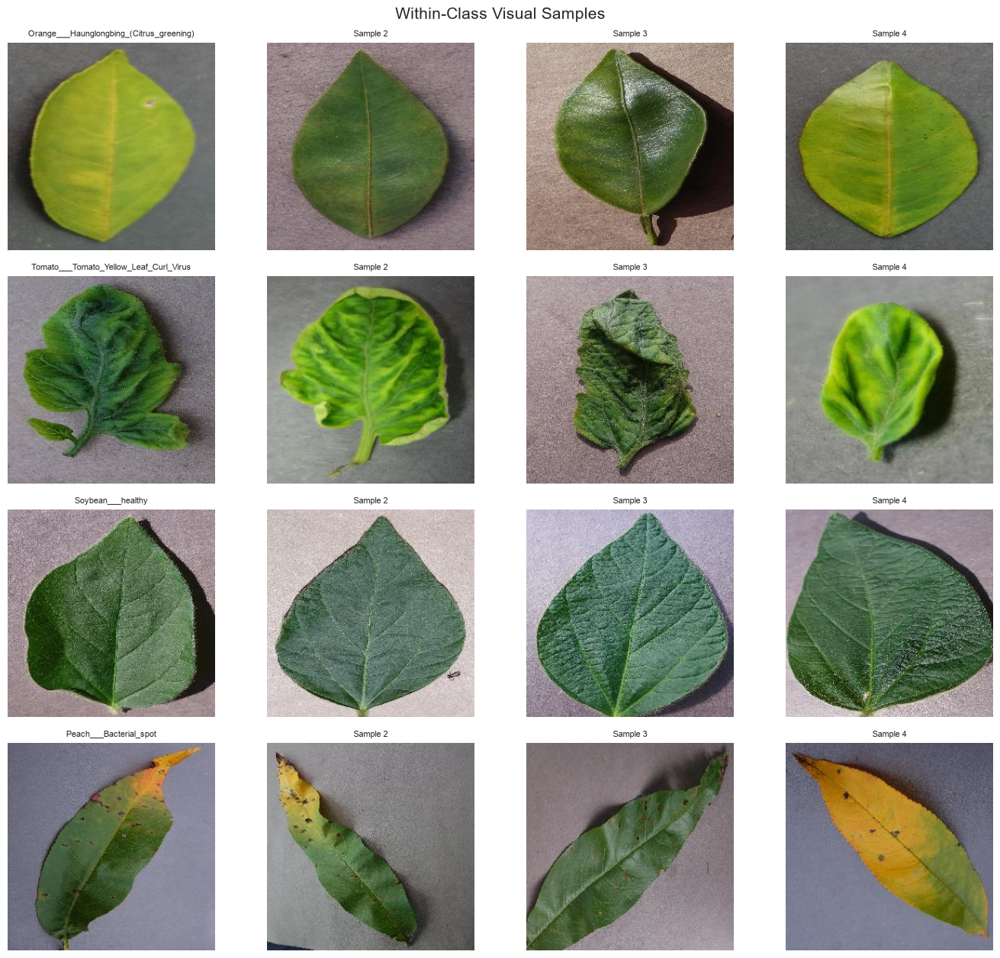

In [13]:
selected_classes = class_distribution_df["class"].head(4).tolist()

fig, axes = plt.subplots(
    len(selected_classes), 4, figsize=(14, 3.2 * len(selected_classes))
)
axes = np.array(axes).reshape(len(selected_classes), 4)

for row, class_name in enumerate(selected_classes):
    class_paths = valid_df.loc[valid_df["class"] == class_name, "path"].tolist()
    chosen = rng.sample(class_paths, min(4, len(class_paths)))

    for col in range(4):
        ax = axes[row, col]
        if col < len(chosen):
            with Image.open(chosen[col]) as source:
                ax.imshow(ImageOps.exif_transpose(source).convert("RGB"))
            ax.set_title(class_name if col == 0 else f"Sample {col + 1}", fontsize=8)
        ax.axis("off")

plt.suptitle("Within-Class Visual Samples", fontsize=15)
plt.tight_layout()
plt.show()

## 8. Image Quality Audit

### Objective
Assess the quality and consistency of the images using the measurements from Section 5, flag images that may need visual review, and document potential issues before preprocessing. Measured concerns are kept separate from confirmed defects.

### 8.1 Overall Quality Statistics

These statistics describe the dataset; they do not by themselves decide whether an image should be removed.

In [14]:
metric_columns = [
    "brightness",
    "contrast",
    "dark_pixel_pct",
    "bright_pixel_pct",
    "mean_saturation",
    "sharpness_laplacian_var",
]

display(
    valid_quality_df[metric_columns]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .T.round(3)
)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
brightness,54305.0,120.703,19.509,8.246,77.051,92.107,108.755,119.878,130.888,154.927,173.902,235.059
contrast,54305.0,40.170,11.593,7.456,16.651,21.431,31.447,40.506,48.516,58.533,68.073,93.371
dark_pixel_pct,54305.0,1.075,5.996,0.000,0.000,0.000,0.000,0.021,0.182,1.741,35.218,91.263
bright_pixel_pct,54305.0,0.118,1.167,0.000,0.000,0.000,0.000,0.002,0.034,0.299,2.008,71.635
mean_saturation,54305.0,68.602,21.490,12.228,30.972,38.420,52.623,65.990,81.376,109.353,126.068,230.456
sharpness_laplacian_var,54305.0,3828.493,3590.651,4.439,35.189,79.848,910.135,3068.577,5806.412,10037.016,17130.103,27301.064


### 8.2 Quality Metric Distributions

Unusual values should be investigated rather than automatically treated as defects.

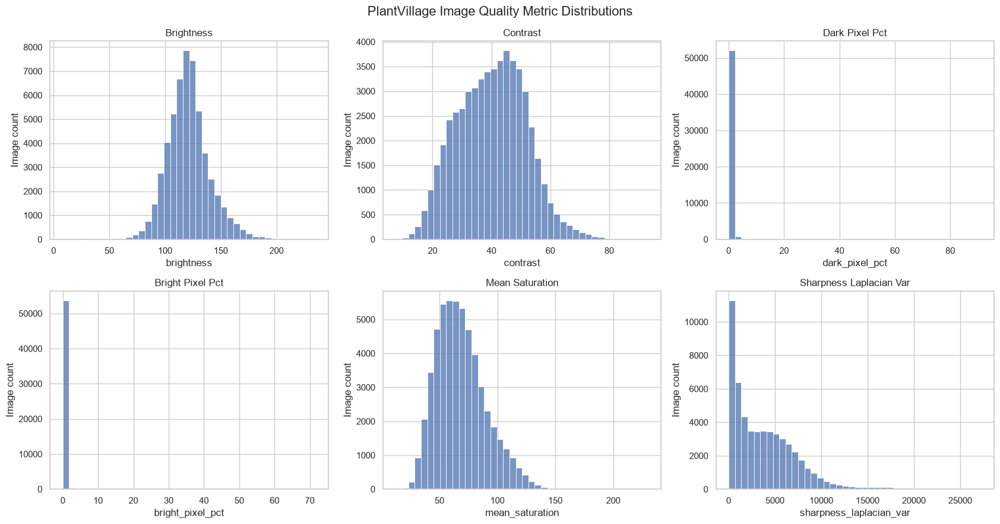

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, column in zip(axes.flat, metric_columns):
    sns.histplot(data=valid_quality_df, x=column, bins=40, ax=ax)
    ax.set_title(column.replace("_", " ").title())
    ax.set_ylabel("Image count")

plt.suptitle("PlantVillage Image Quality Metric Distributions", fontsize=16)
plt.tight_layout()
plt.show()

### 8.3 Class-Level Quality Comparison

Compare quality characteristics across classes to spot differences related to lighting, backgrounds, or image content.

In [16]:
class_quality_summary = (
    valid_quality_df
    .groupby("class")
    .agg(
        image_count=("path", "count"),
        mean_brightness=("brightness", "mean"),
        median_brightness=("brightness", "median"),
        mean_contrast=("contrast", "mean"),
        mean_saturation=("mean_saturation", "mean"),
        median_sharpness=("sharpness_laplacian_var", "median"),
        mean_dark_pixel_pct=("dark_pixel_pct", "mean"),
        mean_bright_pixel_pct=("bright_pixel_pct", "mean"),
    )
    .sort_values("image_count", ascending=False)
)

display(class_quality_summary.round(3))

,image_count,mean_brightness,median_brightness,mean_contrast,mean_saturation,median_sharpness,mean_dark_pixel_pct,mean_bright_pixel_pct
class,,,,,,,,
Orange___Haunglongbing_(Citrus_greening),5507,103.864,103.526,30.969,101.045,385.856,0.022,0.012
Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357,114.198,113.434,34.714,76.665,363.210,0.116,0.003
Soybean___healthy,5090,138.480,138.102,47.308,47.871,5373.416,0.051,0.221
Peach___Bacterial_spot,2297,117.539,117.645,32.992,65.651,1115.079,0.147,0.008
Tomato___Bacterial_spot,2127,104.916,102.962,33.415,56.956,986.316,0.012,0.000
Tomato___Late_blight,1909,113.427,118.495,39.590,54.958,1617.803,6.023,0.057
Squash___Powdery_mildew,1835,128.301,125.221,29.082,66.475,4972.688,0.015,0.029
Tomato___Septoria_leaf_spot,1771,130.901,127.950,37.840,65.626,4746.503,0.460,0.052
Tomato___Spider_mites Two-spotted_spider_mite,1676,119.272,120.132,44.563,59.383,6947.427,0.164,0.015


Boxplots compare brightness and sharpness across classes. Outlying values are hidden in the plots for readability but remain in the data.

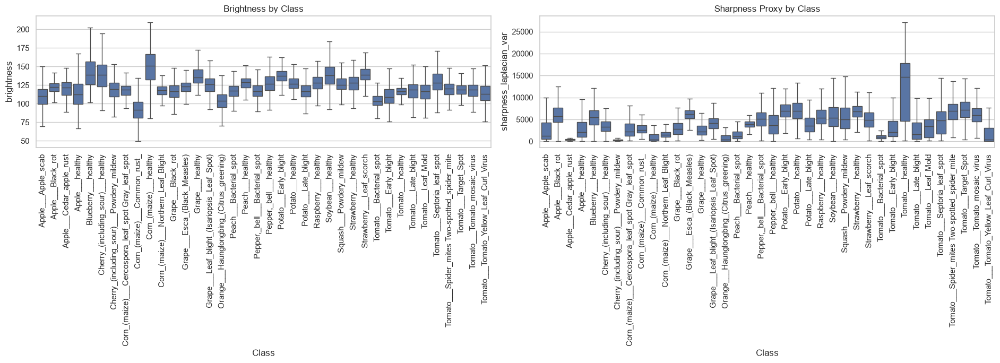

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(19, 7))

sns.boxplot(data=valid_quality_df, x="class", y="brightness",
            ax=axes[0], showfliers=False)
axes[0].set_title("Brightness by Class")
axes[0].tick_params(axis="x", rotation=90)
axes[0].set_xlabel("Class")

sns.boxplot(data=valid_quality_df, x="class", y="sharpness_laplacian_var",
            ax=axes[1], showfliers=False)
axes[1].set_title("Sharpness Proxy by Class")
axes[1].tick_params(axis="x", rotation=90)
axes[1].set_xlabel("Class")

plt.tight_layout()
plt.show()

### 8.4 Screening Rules for Potential Quality Issues

Images are flagged for review using transparent, configurable rules:

- **Very low brightness:** mean brightness below 50.
- **Very low contrast:** grayscale standard deviation below 20.
- **Potential blur:** sharpness proxy at or below the 5th percentile of the valid dataset.
- **Potential clipping:** at least 20% of pixels are extremely dark or extremely bright.

These thresholds are screening rules, not universal quality standards. An image can trigger more than one rule, and a flag does not mean the image should be removed.

In [18]:
LOW_BRIGHTNESS_THRESHOLD = 50
LOW_CONTRAST_THRESHOLD = 20
SHARPNESS_REVIEW_PERCENTILE = 0.05
CLIPPING_PERCENT_THRESHOLD = 20

sharpness_threshold = valid_quality_df["sharpness_laplacian_var"].quantile(
    SHARPNESS_REVIEW_PERCENTILE
)

valid_quality_df["flag_low_brightness"] = (
    valid_quality_df["brightness"] < LOW_BRIGHTNESS_THRESHOLD
)
valid_quality_df["flag_low_contrast"] = (
    valid_quality_df["contrast"] < LOW_CONTRAST_THRESHOLD
)
valid_quality_df["flag_low_sharpness"] = (
    valid_quality_df["sharpness_laplacian_var"] <= sharpness_threshold
)
valid_quality_df["flag_extreme_clipping"] = (
    (valid_quality_df["dark_pixel_pct"] >= CLIPPING_PERCENT_THRESHOLD)
    | (valid_quality_df["bright_pixel_pct"] >= CLIPPING_PERCENT_THRESHOLD)
)

flag_columns = [
    "flag_low_brightness",
    "flag_low_contrast",
    "flag_low_sharpness",
    "flag_extreme_clipping",
]

valid_quality_df["quality_flag_count"] = valid_quality_df[flag_columns].sum(axis=1)
valid_quality_df["needs_visual_review"] = valid_quality_df["quality_flag_count"] > 0

quality_review_df = valid_quality_df[valid_quality_df["needs_visual_review"]].copy()

flag_summary = pd.DataFrame({
    "Review reason": [
        "Low brightness",
        "Low contrast",
        "Low sharpness proxy",
        "Extreme dark/bright pixel clipping",
        "Any quality flag (unique images)",
    ],
    "Image count": [
        int(valid_quality_df["flag_low_brightness"].sum()),
        int(valid_quality_df["flag_low_contrast"].sum()),
        int(valid_quality_df["flag_low_sharpness"].sum()),
        int(valid_quality_df["flag_extreme_clipping"].sum()),
        int(valid_quality_df["needs_visual_review"].sum()),
    ],
})

print("QUALITY REVIEW SUMMARY")
print("=" * 45)
print("Low-sharpness threshold (5th percentile):", round(sharpness_threshold, 3))
print("Images are flagged only; no files have been removed.")
display(flag_summary)

print("\nTop 30 flagged images (most flags first, then lowest sharpness):")
display(
    quality_review_df[
        ["class", "filename", "brightness", "contrast",
         "sharpness_laplacian_var", "dark_pixel_pct",
         "bright_pixel_pct", "quality_flag_count", "path"]
    ]
    .sort_values(["quality_flag_count", "sharpness_laplacian_var"],
                 ascending=[False, True])
    .head(30)
)

QUALITY REVIEW SUMMARY
Low-sharpness threshold (5th percentile): 79.848
Images are flagged only; no files have been removed.


,Review reason,Image count
0,Low brightness,151
1,Low contrast,1808
2,Low sharpness proxy,2716
3,Extreme dark/bright pixel clipping,1173
4,Any quality flag (unique images),4933



Top 30 flagged images (most flags first, then lowest sharpness):


,class,filename,brightness,contrast,sharpness_laplacian_var,dark_pixel_pct,bright_pixel_pct,quality_flag_count,path
8862,Corn_(maize)___healthy,7bedea19-5d9f-4bee-a1a1-091a168d4672___R.S_HL ...,163.982147,15.973128,4.438885,0.0,0.007629,2,C:\Users\omarw\Downloads\PlantVillage_Project\...
53249,Tomato___Tomato_Yellow_Leaf_Curl_Virus,cd37cbce-e141-40a5-8af6-8fa6790c7ed3___UF.GRC_...,112.304276,17.532431,5.033697,0.0,0.000000,2,C:\Users\omarw\Downloads\PlantVillage_Project\...
52448,Tomato___Tomato_Yellow_Leaf_Curl_Virus,a5b5d284-5081-4340-9cfa-be58ed74aea3___UF.GRC_...,122.512619,17.522522,5.205840,0.0,0.000000,2,C:\Users\omarw\Downloads\PlantVillage_Project\...
8451,Corn_(maize)___healthy,205f8753-7598-4469-86c2-59307f90e85c___R.S_HL ...,177.452499,19.769432,7.657609,0.0,1.225281,2,C:\Users\omarw\Downloads\PlantVillage_Project\...
53106,Tomato___Tomato_Yellow_Leaf_Curl_Virus,c6380761-954b-4a14-b686-05ce51868611___UF.GRC_...,132.973358,18.371521,9.230139,0.0,0.000000,2,C:\Users\omarw\Downloads\PlantVillage_Project\...
53016,Tomato___Tomato_Yellow_Leaf_Curl_Virus,c1608c9f-8ae7-444b-afa5-bc50051e2d1a___UF.GRC_...,133.797684,16.218050,9.881795,0.0,0.000000,2,C:\Users\omarw\Downloads\PlantVillage_Project\...
49167,Tomato___Tomato_Yellow_Leaf_Curl_Virus,0a9ce4eb-961b-4f11-a06f-2946cfd0d562___UF.GRC_...,125.182098,12.642920,10.171833,0.0,0.000000,2,C:\Users\omarw\Downloads\PlantVillage_Project\...
9089,Corn_(maize)___healthy,adda5157-0c8f-4077-b89f-8be51e8cb9d8___R.S_HL ...,137.478363,15.650664,10.443408,0.0,0.000000,2,C:\Users\omarw\Downloads\PlantVillage_Project\...
50341,Tomato___Tomato_Yellow_Leaf_Curl_Virus,41b73fb7-4f01-4519-8876-afb3c716fbe1___UF.GRC_...,134.762222,19.053867,10.521080,0.0,0.000000,2,C:\Users\omarw\Downloads\PlantVillage_Project\...
9321,Corn_(maize)___healthy,e30f6f58-1ca0-44a0-bfd6-e3472122a5c7___R.S_HL ...,136.530823,14.135475,11.887532,0.0,0.000000,2,C:\Users\omarw\Downloads\PlantVillage_Project\...


### 8.5 Visual Review of Flagged Images

Display the images with the most flags (lowest sharpness breaks ties). The goal is to judge whether the rules catch genuine problems or valid images with naturally dark, textured, or low-detail content.

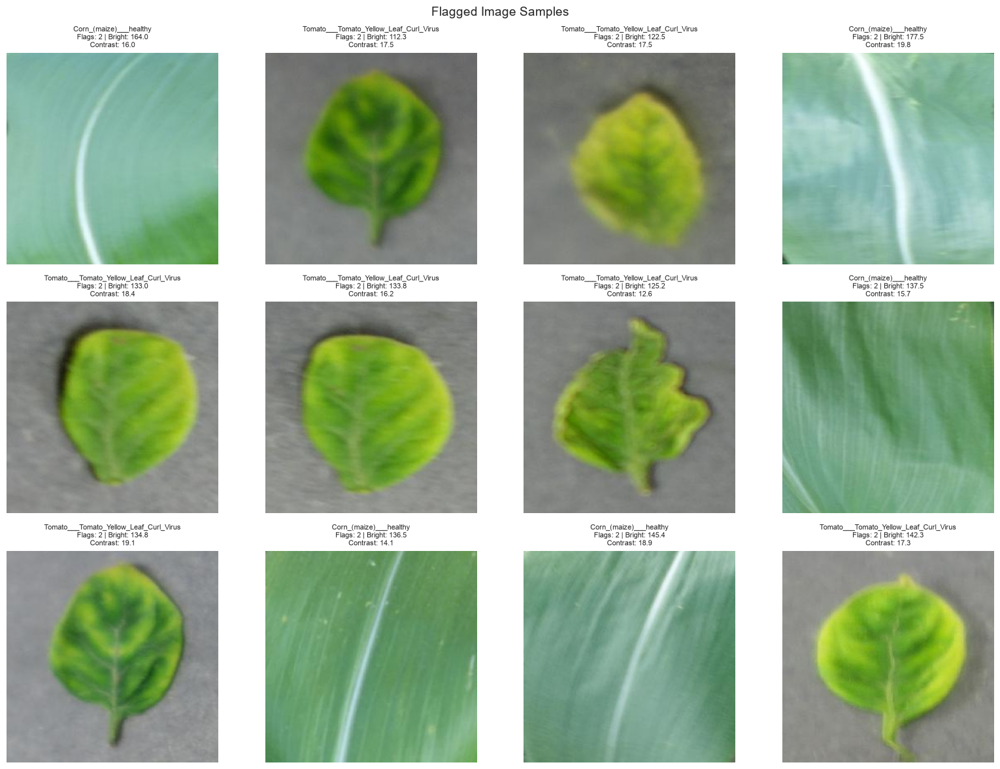

In [19]:
def display_quality_samples(dataframe, n=12, title="Flagged Image Samples"):
    if dataframe.empty:
        print("No images were flagged by the selected rules.")
        return

    sample = dataframe.head(n)
    ncols = 4
    nrows = int(np.ceil(len(sample) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, sample.iterrows()):
        with Image.open(row["path"]) as img:
            ax.imshow(ImageOps.exif_transpose(img).convert("RGB"))
        ax.set_title(
            f'{row["class"]}\n'
            f'Flags: {row["quality_flag_count"]} | Bright: {row["brightness"]:.1f}\n'
            f'Contrast: {row["contrast"]:.1f}',
            fontsize=8
        )
        ax.axis("off")

    for ax in axes[len(sample):]:
        ax.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


display_quality_samples(
    quality_review_df.sort_values(
        ["quality_flag_count", "sharpness_laplacian_var"],
        ascending=[False, True]
    ),
    n=12
)

### 8.6 Visual Inspection Findings

Based on the random samples and the flagged images:

- Images generally contain recognizable plant leaves.
- Brightness and lighting conditions vary.
- Some images have low brightness or low contrast.
- Backgrounds vary, including black, gray, and natural backgrounds.
- Some images show visible disease symptoms, discoloration, and leaf damage.
- No image is removed automatically because of brightness, contrast, sharpness, or clipping measurements alone.

**Conclusion:** The dataset is visually diverse in lighting, backgrounds, and image quality. Preprocessing should keep input quality consistent while preserving disease-related features.

## 9. Duplicate and Near-Duplicate Detection

### Objective
Find exact and visually similar images to detect redundancy and potential data leakage before preprocessing and model training. Only readable images are hashed.

### 9.1 Exact Duplicates (SHA-256)

Identical hashes mean byte-identical files. Duplicates within one class are redundant copies; duplicates across classes need review because the label may be ambiguous.

In [20]:
def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


hash_df = valid_df[["path", "relative_path", "class", "filename"]].copy()
hash_df["sha256"] = [
    sha256_file(p) for p in tqdm(hash_df["path"], desc="Hashing images")
]

# Files that share a hash with at least one other file
duplicate_files = hash_df[hash_df.duplicated("sha256", keep=False)].copy()

group_info = duplicate_files.groupby("sha256").agg(
    group_file_count=("path", "count"),
    n_classes=("class", "nunique"),
    group_classes=("class", lambda s: " | ".join(sorted(s.unique()))),
)

duplicates_df = duplicate_files.merge(group_info, on="sha256")
duplicates_df["duplicate_type"] = np.where(
    duplicates_df["n_classes"] == 1, "same_class", "cross_class"
)
duplicates_df["duplicate_group"] = (
    duplicates_df.groupby("sha256", sort=True).ngroup() + 1
)
duplicates_df = duplicates_df.sort_values(
    ["duplicate_group", "relative_path"]
).reset_index(drop=True)

duplicate_group_count = duplicates_df["duplicate_group"].nunique()

print("EXACT DUPLICATE ANALYSIS")
print("=" * 50)
print("Images hashed:", len(hash_df))
print("Duplicate groups:", duplicate_group_count)
print("Images involved in duplicates:", len(duplicates_df))
print("Extra duplicate copies:", len(duplicates_df) - duplicate_group_count)
print("Same-class duplicate groups:",
      duplicates_df.loc[duplicates_df["duplicate_type"] == "same_class",
                        "duplicate_group"].nunique())
print("Cross-class duplicate groups:",
      duplicates_df.loc[duplicates_df["duplicate_type"] == "cross_class",
                        "duplicate_group"].nunique())

display(duplicates_df.head(20))

Hashing images: 100%|██████████| 54305/54305 [00:36<00:00, 1498.77it/s]


EXACT DUPLICATE ANALYSIS
Images hashed: 54305
Duplicate groups: 21
Images involved in duplicates: 42
Extra duplicate copies: 21
Same-class duplicate groups: 21
Cross-class duplicate groups: 0


,path,relative_path,class,filename,sha256,group_file_count,n_classes,group_classes,duplicate_type,duplicate_group
0,C:\Users\omarw\Downloads\PlantVillage_Project\...,Tomato___healthy\488feb1c-4b9f-44e7-8aa6-4103a...,Tomato___healthy,488feb1c-4b9f-44e7-8aa6-4103a9601f5f___GH_HL L...,12852b3616bcf0ba39b03b5677e74f50f5f6abf4d38957...,2,1,Tomato___healthy,same_class,1
1,C:\Users\omarw\Downloads\PlantVillage_Project\...,Tomato___healthy\a5de43e7-fc2f-4a14-a8e6-c0f2f...,Tomato___healthy,a5de43e7-fc2f-4a14-a8e6-c0f2f94c84f1___GH_HL L...,12852b3616bcf0ba39b03b5677e74f50f5f6abf4d38957...,2,1,Tomato___healthy,same_class,1
2,C:\Users\omarw\Downloads\PlantVillage_Project\...,Apple___healthy\f2cda910-55c7-46d7-b1a2-9a3bb9...,Apple___healthy,f2cda910-55c7-46d7-b1a2-9a3bb9792148___RS_HL 6...,262198126fd6d982126b69261723e13abb36b383138797...,2,1,Apple___healthy,same_class,2
3,C:\Users\omarw\Downloads\PlantVillage_Project\...,Apple___healthy\fdbfa6f7-f887-442d-8df1-1f0cf8...,Apple___healthy,fdbfa6f7-f887-442d-8df1-1f0cf839fc4d___RS_HL 6...,262198126fd6d982126b69261723e13abb36b383138797...,2,1,Apple___healthy,same_class,2
4,C:\Users\omarw\Downloads\PlantVillage_Project\...,Tomato___healthy\068e324c-faf6-40d6-8f83-57890...,Tomato___healthy,068e324c-faf6-40d6-8f83-578907f1cac5___GH_HL L...,2a05a74db3a270ac0ec77c00ebe89a332eed5898194351...,2,1,Tomato___healthy,same_class,3
5,C:\Users\omarw\Downloads\PlantVillage_Project\...,Tomato___healthy\34c81c57-e1fa-49dd-a49d-34fe8...,Tomato___healthy,34c81c57-e1fa-49dd-a49d-34fe8b2385fe___GH_HL L...,2a05a74db3a270ac0ec77c00ebe89a332eed5898194351...,2,1,Tomato___healthy,same_class,3
6,C:\Users\omarw\Downloads\PlantVillage_Project\...,Tomato___Late_blight\5f21282c-e2ef-4c4a-ace1-b...,Tomato___Late_blight,5f21282c-e2ef-4c4a-ace1-b5701fe7effc___GHLB2 L...,2aeb7479e975df37dfb54aa7b403f57f2ad90b018c3780...,2,1,Tomato___Late_blight,same_class,4
7,C:\Users\omarw\Downloads\PlantVillage_Project\...,Tomato___Late_blight\e5d707cd-077c-43af-bda9-6...,Tomato___Late_blight,e5d707cd-077c-43af-bda9-6138e516ff51___GHLB2 L...,2aeb7479e975df37dfb54aa7b403f57f2ad90b018c3780...,2,1,Tomato___Late_blight,same_class,4
8,C:\Users\omarw\Downloads\PlantVillage_Project\...,Tomato___healthy\9662364c-aaba-45e3-b907-10792...,Tomato___healthy,9662364c-aaba-45e3-b907-10792d60578c___GH_HL L...,32e9ffabaa054c19ae8df95e94fbd7a25105defdea1214...,2,1,Tomato___healthy,same_class,5
9,C:\Users\omarw\Downloads\PlantVillage_Project\...,Tomato___healthy\d2ce7896-6fa4-45e6-96c5-d162d...,Tomato___healthy,d2ce7896-6fa4-45e6-96c5-d162da0e3e1c___GH_HL L...,32e9ffabaa054c19ae8df95e94fbd7a25105defdea1214...,2,1,Tomato___healthy,same_class,5


### 9.2 Cross-Class Exact Duplicates

The same image appearing under more than one class label.

In [21]:
cross_class_duplicates = duplicates_df[
    duplicates_df["duplicate_type"] == "cross_class"
].copy()

print("Cross-class exact-duplicate groups:",
      cross_class_duplicates["duplicate_group"].nunique())
display(cross_class_duplicates)

Cross-class exact-duplicate groups: 0


,path,relative_path,class,filename,sha256,group_file_count,n_classes,group_classes,duplicate_type,duplicate_group


### 9.3 Perceptual Hashes (pHash)

Perceptual hashes represent how an image looks, so visually similar images can be found even when their file contents differ.

In [22]:
phash_records = []

for path_string, class_name, filename in tqdm(
    zip(valid_df["path"], valid_df["class"], valid_df["filename"]),
    total=len(valid_df),
    desc="Computing pHash"
):
    try:
        with Image.open(path_string) as img:
            img_hash = imagehash.phash(img)
        phash_records.append({
            "class": class_name,
            "filename": filename,
            "path": path_string,
            "phash": int(str(img_hash), 16),
        })
    except Exception as exc:
        print(f"Error processing {filename}: {exc}")

phash_df = pd.DataFrame(phash_records)

print("PERCEPTUAL HASH SUMMARY")
print("=" * 50)
print("Images processed:", len(phash_df))
print("Unique perceptual hashes:", phash_df["phash"].nunique())

Computing pHash: 100%|██████████| 54305/54305 [01:12<00:00, 746.83it/s] 

PERCEPTUAL HASH SUMMARY
Images processed: 54305
Unique perceptual hashes: 54283


### 9.4 Near-Duplicate Search with a BK-Tree

A BK-tree over Hamming distances between pHashes efficiently finds image pairs within the chosen distance threshold. Byte-identical pairs are skipped because Section 9.1 already covers them. The pairs are candidates, not confirmed duplicates.

In [23]:
HAMMING_THRESHOLD = 4


def hamming_distance(hash1, hash2):
    # Hamming distance between two 64-bit hashes
    return (hash1 ^ hash2).bit_count()


class BKTree:

    def __init__(self):
        self.root = None

    def add(self, value, index):
        if self.root is None:
            self.root = {"value": value, "indices": [index], "children": {}}
            return

        node = self.root
        while True:
            distance = hamming_distance(value, node["value"])

            if distance == 0:
                node["indices"].append(index)
                return

            if distance not in node["children"]:
                node["children"][distance] = {
                    "value": value, "indices": [index], "children": {}
                }
                return

            node = node["children"][distance]

    def search(self, value, threshold):
        if self.root is None:
            return []

        results = []
        stack = [self.root]

        while stack:
            node = stack.pop()
            distance = hamming_distance(value, node["value"])

            if distance <= threshold:
                results.extend([(idx, distance) for idx in node["indices"]])

            lower = distance - threshold
            upper = distance + threshold

            for edge, child in node["children"].items():
                if lower <= edge <= upper:
                    stack.append(child)

        return results


sha_lookup = dict(zip(hash_df["path"], hash_df["sha256"]))

tree = BKTree()
near_duplicate_pairs = []

for index, row in phash_df.iterrows():
    matches = tree.search(row["phash"], HAMMING_THRESHOLD)

    for previous_index, distance in matches:
        previous_row = phash_df.loc[previous_index]

        # Skip byte-identical files (already handled as exact duplicates)
        if sha_lookup.get(row["path"]) == sha_lookup.get(previous_row["path"]):
            continue

        near_duplicate_pairs.append({
            "class_1": previous_row["class"],
            "filename_1": previous_row["filename"],
            "class_2": row["class"],
            "filename_2": row["filename"],
            "hamming_distance": distance,
            "path_1": previous_row["path"],
            "path_2": row["path"],
        })

    tree.add(row["phash"], index)

near_duplicates_df = pd.DataFrame(
    near_duplicate_pairs,
    columns=["class_1", "filename_1", "class_2", "filename_2",
             "hamming_distance", "path_1", "path_2"]
)

near_duplicate_image_paths = (
    set(near_duplicates_df["path_1"]) | set(near_duplicates_df["path_2"])
)

print("NEAR-DUPLICATE ANALYSIS")
print("=" * 50)
print("Near-duplicate pairs:", len(near_duplicates_df))
print("Unique images involved:", len(near_duplicate_image_paths))

if near_duplicates_df.empty:
    print("No near-duplicate pairs detected.")
else:
    print("\nHamming distance distribution:")
    display(near_duplicates_df["hamming_distance"].value_counts().sort_index())
    print("\nDetected near-duplicate pairs (first 20):")
    display(near_duplicates_df.head(20))

NEAR-DUPLICATE ANALYSIS
Near-duplicate pairs: 1444
Unique images involved: 1698

Hamming distance distribution:


hamming_distance
0       1
2      96
4    1347
Name: count, dtype: int64


Detected near-duplicate pairs (first 20):


,class_1,filename_1,class_2,filename_2,hamming_distance,path_1,path_2
0,Apple___Black_rot,6af96fb3-002f-48b3-a2e8-fb5cf30dfa63___JR_FrgE...,Apple___Black_rot,f83c1286-8bdb-48e6-ac8f-bd8a5209afc7___JR_FrgE...,4,C:\Users\omarw\Downloads\PlantVillage_Project\...,C:\Users\omarw\Downloads\PlantVillage_Project\...
1,Apple___Black_rot,30aebb07-bde6-44c8-bee2-a06ff42a948d___JR_FrgE...,Apple___Black_rot,fb8255a6-e05d-44d3-a115-80c1e55009bd___JR_FrgE...,4,C:\Users\omarw\Downloads\PlantVillage_Project\...,C:\Users\omarw\Downloads\PlantVillage_Project\...
2,Apple___Black_rot,4eeaca51-3ca2-4afe-884a-d65c2e31e452___JR_FrgE...,Apple___Black_rot,fc5f6bd3-bd4e-4a8c-94d1-d46ea92a3941___JR_FrgE...,4,C:\Users\omarw\Downloads\PlantVillage_Project\...,C:\Users\omarw\Downloads\PlantVillage_Project\...
3,Apple___healthy,298c8daf-43cc-4f65-b2db-65623425e5f8___RS_HL 6...,Apple___healthy,9fc6acc1-0394-498d-b51c-d2e92febae55___RS_HL 6...,4,C:\Users\omarw\Downloads\PlantVillage_Project\...,C:\Users\omarw\Downloads\PlantVillage_Project\...
4,Apple___healthy,375f1e44-235c-4ef0-a156-077b71abeed3___RS_HL 8...,Apple___healthy,abc9f5f6-ea98-46c0-8df7-2986969318bf___RS_HL 5...,4,C:\Users\omarw\Downloads\PlantVillage_Project\...,C:\Users\omarw\Downloads\PlantVillage_Project\...
5,Apple___healthy,946b311a-cb67-46d4-8c8b-0d91ebd456f3___RS_HL 5...,Apple___healthy,b6808ea5-f26b-49fa-87b2-a1bbbc98d74c___RS_HL 6...,4,C:\Users\omarw\Downloads\PlantVillage_Project\...,C:\Users\omarw\Downloads\PlantVillage_Project\...
6,Apple___Apple_scab,f6946261-1a18-4306-ba87-ca25344d9bd2___FREC_Sc...,Blueberry___healthy,23d13863-7320-427f-8559-9665257b9540___RS_HL 2...,4,C:\Users\omarw\Downloads\PlantVillage_Project\...,C:\Users\omarw\Downloads\PlantVillage_Project\...
7,Blueberry___healthy,163fa1ca-f6b9-4ce4-8218-771750b3043f___RS_HL 5...,Blueberry___healthy,3b4ab949-7b1d-4127-a1d3-8f125989f495___RS_HL 5...,4,C:\Users\omarw\Downloads\PlantVillage_Project\...,C:\Users\omarw\Downloads\PlantVillage_Project\...
8,Blueberry___healthy,201aef7f-4e1c-4197-ae37-66ca340909bc___RS_HL 0...,Blueberry___healthy,76610fbe-b5da-460e-ae69-29e89b02f1dd___RS_HL 0...,4,C:\Users\omarw\Downloads\PlantVillage_Project\...,C:\Users\omarw\Downloads\PlantVillage_Project\...
9,Blueberry___healthy,39a6957f-2837-4a39-bb60-a8a3c155290f___RS_HL 5...,Blueberry___healthy,7b7ada95-0a08-4b41-a028-e4ba89ca33c4___RS_HL 5...,4,C:\Users\omarw\Downloads\PlantVillage_Project\...,C:\Users\omarw\Downloads\PlantVillage_Project\...


### 9.5 Cross-Class Near-Duplicates

Visually similar images assigned to different classes.

In [24]:
cross_class_near_duplicates = near_duplicates_df[
    near_duplicates_df["class_1"] != near_duplicates_df["class_2"]
].copy()

print("Cross-class near-duplicate pairs:", len(cross_class_near_duplicates))
display(cross_class_near_duplicates.head(20))

Cross-class near-duplicate pairs: 300


,class_1,filename_1,class_2,filename_2,hamming_distance,path_1,path_2
6,Apple___Apple_scab,f6946261-1a18-4306-ba87-ca25344d9bd2___FREC_Sc...,Blueberry___healthy,23d13863-7320-427f-8559-9665257b9540___RS_HL 2...,4,C:\Users\omarw\Downloads\PlantVillage_Project\...,C:\Users\omarw\Downloads\PlantVillage_Project\...
16,Blueberry___healthy,e35a63f4-5fa8-40af-9e59-a63b67801bcf___RS_HL 4...,Cherry_(including_sour)___healthy,0a273dc4-db45-4936-aee3-59919e1df44f___JR_HL 9...,4,C:\Users\omarw\Downloads\PlantVillage_Project\...,C:\Users\omarw\Downloads\PlantVillage_Project\...
17,Apple___healthy,5941b857-a525-4aff-ba20-def608d63c4d___RS_HL 6...,Cherry_(including_sour)___healthy,162dc895-00e6-4f02-ab49-a7030ec8984d___JR_HL 9...,4,C:\Users\omarw\Downloads\PlantVillage_Project\...,C:\Users\omarw\Downloads\PlantVillage_Project\...
19,Blueberry___healthy,e1bba6b4-45e5-4d1f-b58f-01ef97525cc6___RS_HL 2...,Cherry_(including_sour)___healthy,3701b877-df2b-49cd-9bb9-066dd6f2f206___JR_HL 9...,4,C:\Users\omarw\Downloads\PlantVillage_Project\...,C:\Users\omarw\Downloads\PlantVillage_Project\...
20,Apple___healthy,51cb81e8-dd15-40cd-b4f2-5287379dfe74___RS_HL 6...,Cherry_(including_sour)___healthy,3aaba56c-080d-4a21-b2d8-8fe69189a720___JR_HL 4...,4,C:\Users\omarw\Downloads\PlantVillage_Project\...,C:\Users\omarw\Downloads\PlantVillage_Project\...
22,Apple___healthy,b0ba7a6d-95eb-44e2-a2a5-4d9ef9b489d7___RS_HL 5...,Cherry_(including_sour)___healthy,48476597-1b5c-4d55-bd30-80059a2356bf___JR_HL 9...,4,C:\Users\omarw\Downloads\PlantVillage_Project\...,C:\Users\omarw\Downloads\PlantVillage_Project\...
64,Grape___Black_rot,24076a50-f715-4b02-b1fc-d5b83ab06174___FAM_B.R...,Orange___Haunglongbing_(Citrus_greening),11b4a4de-c43d-48ac-a5a3-00b0875f6959___CREC_HL...,4,C:\Users\omarw\Downloads\PlantVillage_Project\...,C:\Users\omarw\Downloads\PlantVillage_Project\...
90,Cherry_(including_sour)___Powdery_mildew,341d8850-26e0-4ac5-a560-da2be3fc4b24___FREC_Pw...,Orange___Haunglongbing_(Citrus_greening),bc070003-a6bb-4cc7-8e4b-4f5d074dd408___CREC_HL...,4,C:\Users\omarw\Downloads\PlantVillage_Project\...,C:\Users\omarw\Downloads\PlantVillage_Project\...
119,Cherry_(including_sour)___healthy,55df59e1-73fb-4feb-8099-0b832bb3fb81___JR_HL 9...,Peach___healthy,02070622-2fd7-40d5-9470-27e513ea8a90___Rutg._H...,4,C:\Users\omarw\Downloads\PlantVillage_Project\...,C:\Users\omarw\Downloads\PlantVillage_Project\...
122,Orange___Haunglongbing_(Citrus_greening),0b4118d9-903b-4883-a8e2-d802d524e1d6___CREC_HL...,"Pepper,_bell___healthy",1663be64-8704-420b-8f9e-eb6265029f50___JR_HL 7...,4,C:\Users\omarw\Downloads\PlantVillage_Project\...,C:\Users\omarw\Downloads\PlantVillage_Project\...


### 9.6 Visual Check of Near-Duplicate Pairs

Display selected pairs for manual confirmation of the detection results.

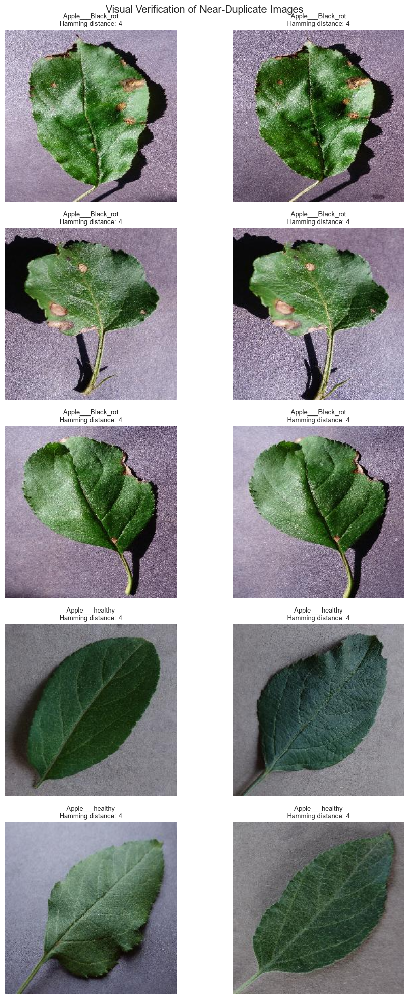

In [25]:
def inspect_duplicate_pairs(df, n=5):
    if df.empty:
        print("No pairs available for inspection.")
        return

    sample = df.head(n)
    fig, axes = plt.subplots(len(sample), 2, figsize=(10, 4 * len(sample)))
    axes = np.array(axes).reshape(len(sample), 2)

    for i, (_, row) in enumerate(sample.iterrows()):
        for col, (path_key, class_key) in enumerate(
            [("path_1", "class_1"), ("path_2", "class_2")]
        ):
            with Image.open(row[path_key]) as img:
                axes[i][col].imshow(img.convert("RGB"))
            axes[i][col].set_title(
                f"{row[class_key]}\nHamming distance: {row['hamming_distance']}",
                fontsize=9
            )
            axes[i][col].axis("off")

    plt.suptitle("Visual Verification of Near-Duplicate Images")
    plt.tight_layout()
    plt.show()


inspect_duplicate_pairs(near_duplicates_df, n=5)

## 10. Data Cleaning Decisions

### Objective
Turn the findings above into a documented, deterministic inventory of usable images while leaving the original files untouched.

### Rules

- **Unreadable files:** excluded from the usable inventory and reported for inspection.
- **Same-class exact duplicates:** keep one copy (first by relative path); mark the remaining copies as redundant and exclude them.
- **Cross-class exact duplicates:** keep all copies but flag them for manual label review.
- **Quality flags** (Section 8) and **near-duplicate candidates** (Section 9.4): keep the images and flag them for review. They are not removed automatically.

### 10.1 Apply the Rules

In [26]:
cleaning_df = validation_df.merge(hash_df[["path", "sha256"]], on="path", how="left")
cleaning_df["cleaning_status"] = "keep"
cleaning_df["cleaning_reason"] = "Readable image; no exact duplicate detected"

# Unreadable files
invalid_mask = cleaning_df["status"] == "invalid"
cleaning_df.loc[invalid_mask, "cleaning_status"] = "exclude_invalid"
cleaning_df.loc[invalid_mask, "cleaning_reason"] = "Image could not be fully decoded"

# Exact duplicates: deterministic choice, first path in each group is the representative
dup_ranked = duplicates_df.sort_values(["duplicate_group", "relative_path"]).copy()
dup_ranked["rank_in_group"] = dup_ranked.groupby("duplicate_group").cumcount()

same_class = dup_ranked[dup_ranked["duplicate_type"] == "same_class"]
retained_paths = set(same_class.loc[same_class["rank_in_group"] == 0, "path"])
redundant_paths = set(same_class.loc[same_class["rank_in_group"] > 0, "path"])
cross_class_paths = set(
    dup_ranked.loc[dup_ranked["duplicate_type"] == "cross_class", "path"]
)

mask = cleaning_df["path"].isin(retained_paths)
cleaning_df.loc[mask, "cleaning_reason"] = "Same-class exact duplicate group; one copy retained"

mask = cleaning_df["path"].isin(cross_class_paths)
cleaning_df.loc[mask, "cleaning_status"] = "review_cross_class_duplicate"
cleaning_df.loc[mask, "cleaning_reason"] = (
    "Exact duplicate appears under multiple class labels; review labels"
)

mask = cleaning_df["path"].isin(redundant_paths)
cleaning_df.loc[mask, "cleaning_status"] = "exclude_redundant_duplicate"
cleaning_df.loc[mask, "cleaning_reason"] = (
    "Redundant same-class exact duplicate; retained representative exists"
)

# Review-only flags (these never change cleaning_status)
cleaning_df["flag_quality_review"] = cleaning_df["path"].isin(
    set(quality_review_df["path"])
)
cleaning_df["flag_near_duplicate_candidate"] = cleaning_df["path"].isin(
    near_duplicate_image_paths
)

usable_statuses = ["keep", "review_cross_class_duplicate"]
clean_inventory = (
    cleaning_df[cleaning_df["cleaning_status"].isin(usable_statuses)]
    .sort_values(["class", "relative_path"])
    .reset_index(drop=True)
)

display(cleaning_df["cleaning_status"].value_counts().rename("count").to_frame())
print("Usable inventory rows:", len(clean_inventory))

,count
cleaning_status,
keep,54284
exclude_redundant_duplicate,21


Usable inventory rows: 54284


### 10.2 Class-Level Changes

Compare raw and usable counts per class. Cross-class duplicates stay included until a person confirms the correct label.

,raw_count,usable_count,difference,usable_percentage
class,,,,
Orange___Haunglongbing_(Citrus_greening),5507,5507,0,10.145
Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357,5357,0,9.868
Soybean___healthy,5090,5090,0,9.377
Peach___Bacterial_spot,2297,2297,0,4.231
Tomato___Bacterial_spot,2127,2127,0,3.918
Tomato___Late_blight,1909,1901,-8,3.502
Squash___Powdery_mildew,1835,1835,0,3.380
Tomato___Septoria_leaf_spot,1771,1771,0,3.262
Tomato___Spider_mites Two-spotted_spider_mite,1676,1676,0,3.087


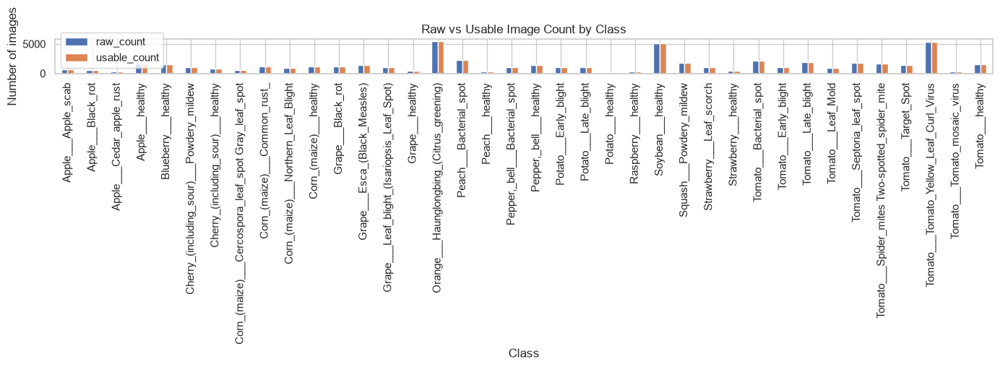

In [27]:
raw_counts = cleaning_df.groupby("class").size().rename("raw_count")
usable_counts = clean_inventory.groupby("class").size().rename("usable_count")

class_summary = pd.concat([raw_counts, usable_counts], axis=1).fillna(0).astype(int)
class_summary["difference"] = class_summary["usable_count"] - class_summary["raw_count"]
class_summary["usable_percentage"] = (
    class_summary["usable_count"] / class_summary["usable_count"].sum() * 100
).round(3)

display(class_summary.sort_values("raw_count", ascending=False))

ax = class_summary[["raw_count", "usable_count"]].plot(kind="bar", figsize=(14, 5))
ax.set_title("Raw vs Usable Image Count by Class")
ax.set_ylabel("Number of images")
ax.set_xlabel("Class")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 10.3 Files Requiring Attention

Review unreadable files and cross-class duplicate groups before deciding whether to repair, relabel, or permanently exclude anything. These subjective decisions are intentionally not automated.

In [28]:
print("INVALID FILES")
display(invalid_df[["relative_path", "file_size_bytes", "error"]])

print("CROSS-CLASS EXACT DUPLICATES")
display(cross_class_duplicates)

INVALID FILES


,relative_path,file_size_bytes,error


CROSS-CLASS EXACT DUPLICATES


,path,relative_path,class,filename,sha256,group_file_count,n_classes,group_classes,duplicate_type,duplicate_group


### 10.4 Cleaning Summary

The summary separates automatic exclusions from review-only flags.

In [29]:
cleaning_summary = pd.DataFrame({
    "Metric": [
        "Images in the original inventory",
        "Classes found",
        "Unreadable images excluded",
        "Same-class exact-duplicate copies excluded",
        "Cross-class exact-duplicate groups flagged",
        "Cross-class exact-duplicate records flagged",
        "Images flagged for quality review (unique, retained)",
        "Near-duplicate candidate pairs (flagged, retained)",
        "Images in near-duplicate candidates (unique, retained)",
        "Images in the usable inventory",
    ],
    "Count": [
        len(cleaning_df),
        int(cleaning_df["class"].nunique()),
        int((cleaning_df["cleaning_status"] == "exclude_invalid").sum()),
        int((cleaning_df["cleaning_status"] == "exclude_redundant_duplicate").sum()),
        int(cross_class_duplicates["duplicate_group"].nunique()),
        int((cleaning_df["cleaning_status"] == "review_cross_class_duplicate").sum()),
        int(cleaning_df["flag_quality_review"].sum()),
        len(near_duplicates_df),
        len(near_duplicate_image_paths),
        len(clean_inventory),
    ],
})

display(cleaning_summary)

# Consistency check: only invalid files and redundant same-class copies are excluded
expected_usable = (
    len(cleaning_df)
    - int((cleaning_df["cleaning_status"] == "exclude_invalid").sum())
    - int((cleaning_df["cleaning_status"] == "exclude_redundant_duplicate").sum())
)
print("Expected usable image count:", expected_usable)
print("Actual usable image count:", len(clean_inventory))
print("Count check passed:", expected_usable == len(clean_inventory))

,Metric,Count
0,Images in the original inventory,54305
1,Classes found,38
2,Unreadable images excluded,0
3,Same-class exact-duplicate copies excluded,21
4,Cross-class exact-duplicate groups flagged,0
5,Cross-class exact-duplicate records flagged,0
6,"Images flagged for quality review (unique, ret...",4933
7,"Near-duplicate candidate pairs (flagged, retai...",1444
8,"Images in near-duplicate candidates (unique, r...",1698
9,Images in the usable inventory,54284


Expected usable image count: 54284
Actual usable image count: 54284
Count check passed: True


## 11. Export and Final Summary

All outputs are reports and inventories; original images are not changed. Files are saved to `OUTPUT_DIR`:

- `raw_inventory.csv`: every discovered image with validation, hash, decision, and review-flag fields.
- `clean_inventory.csv`: images kept for downstream work, including cross-class items flagged for review.
- `invalid_images.csv`: unreadable files.
- `exact_duplicates.csv`: all files in exact-duplicate groups.
- `class_cleaning_summary.csv`: raw and usable counts by class.
- `image_quality_metrics.csv`: per-image quality and color measurements with quality flags.
- `images_for_visual_review.csv`: images flagged by the quality rules.
- `class_quality_summary.csv`: class-level quality statistics.
- `quality_flag_summary.csv`: number of images per quality flag.

In [30]:
cleaning_df.to_csv(OUTPUT_DIR / "raw_inventory.csv", index=False)
clean_inventory.to_csv(OUTPUT_DIR / "clean_inventory.csv", index=False)
invalid_df.to_csv(OUTPUT_DIR / "invalid_images.csv", index=False)
duplicates_df.to_csv(OUTPUT_DIR / "exact_duplicates.csv", index=False)
class_summary.to_csv(OUTPUT_DIR / "class_cleaning_summary.csv")
valid_quality_df.to_csv(OUTPUT_DIR / "image_quality_metrics.csv", index=False)
quality_review_df.to_csv(OUTPUT_DIR / "images_for_visual_review.csv", index=False)
class_quality_summary.to_csv(OUTPUT_DIR / "class_quality_summary.csv")
flag_summary.to_csv(OUTPUT_DIR / "quality_flag_summary.csv", index=False)

print("Saved files:")
for path in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", path.resolve())

print("\nOriginal files modified: No")
print("Count matches expected reference count:",
      len(cleaning_df) == EXPECTED_IMAGE_COUNT)
print(
    "\nHandoff to preprocessing: load reports/clean_inventory.csv and inspect the rows "
    "marked 'review_cross_class_duplicate' (and any quality or near-duplicate flags) "
    "before model preprocessing."
)

Saved files:
- C:\Users\omarw\Downloads\PlantVillage_Project\notebooks\reports\class_cleaning_summary.csv
- C:\Users\omarw\Downloads\PlantVillage_Project\notebooks\reports\class_quality_summary.csv
- C:\Users\omarw\Downloads\PlantVillage_Project\notebooks\reports\clean_inventory.csv
- C:\Users\omarw\Downloads\PlantVillage_Project\notebooks\reports\exact_duplicates.csv
- C:\Users\omarw\Downloads\PlantVillage_Project\notebooks\reports\image_quality_metrics.csv
- C:\Users\omarw\Downloads\PlantVillage_Project\notebooks\reports\images_for_visual_review.csv
- C:\Users\omarw\Downloads\PlantVillage_Project\notebooks\reports\invalid_images.csv
- C:\Users\omarw\Downloads\PlantVillage_Project\notebooks\reports\quality_flag_summary.csv
- C:\Users\omarw\Downloads\PlantVillage_Project\notebooks\reports\raw_inventory.csv

Original files modified: No
Count matches expected reference count: True

Handoff to preprocessing: load reports/clean_inventory.csv and inspect the rows marked 'review_cross_class_

> Do not describe the dataset as fully cleaned while cross-class duplicates remain unresolved or if the detected image count is lower than expected.